In [2]:
%load_ext autoreload
%autoreload 2
import bento as bt
import spatialdata as sd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
sdata = sd.read_zarr("sample_0_spatialdata_prepped_filtered.zarr")

In [4]:


sdata = sd.read_zarr("sample_0_spatialdata_prepped_filtered.zarr")

tx = sdata.points["transcripts"]

print("Sample:", "sample_0")
print("Objects:", len(sdata.shapes["cell_boundaries"]))
print("Transcripts:", len(tx.compute()))
print("Genes:", tx["feature_name"].nunique().compute())

Sample: sample_0
Objects: 152
Transcripts: 1030607
Genes: 4622


Done 🍱: 100%|██████████| 3/3 [00:03<00:00,  1.05s/it]       


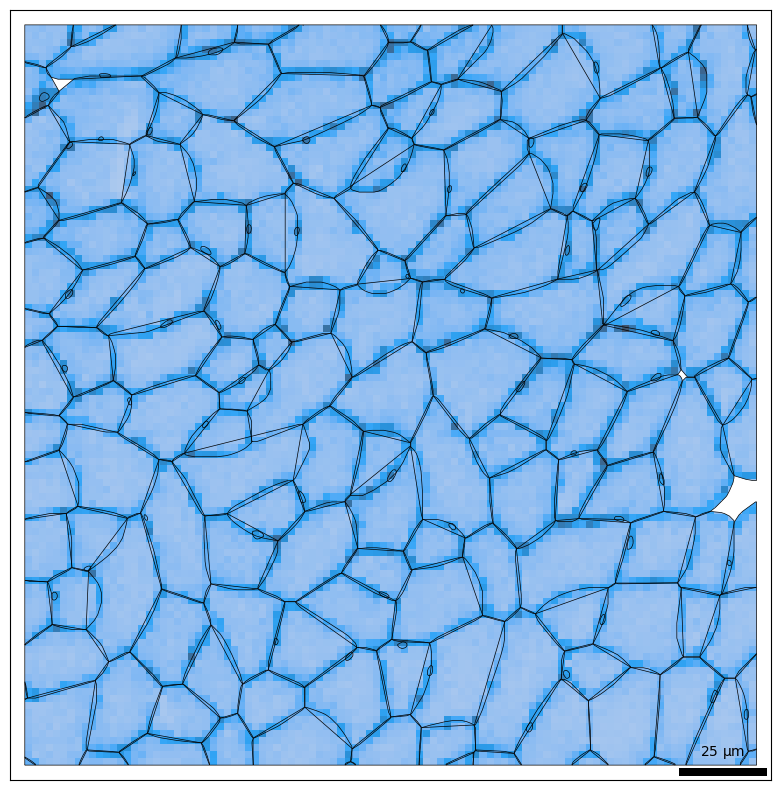

In [5]:

sdata = bt.io.prep(sdata)
plt.figure(figsize=(10, 10))
bt.pl.density(sdata)

In [6]:
sdata = bt.ut.filter_by_gene(sdata, min_count=10)


In [7]:
bt.tl.shape_stats(sdata)


100%|██████████| 3/3 [00:00<00:00, 87.49it/s]


In [38]:
import inspect

print(inspect.getsource(bt.ut.filter_by_gene))

def filter_by_gene(
    sdata: SpatialData,
    min_count: int = 10,
    points_key: str = "transcripts",
    feature_key: str = "feature_name",
) -> SpatialData:
    """Filter out genes with low expression.

    Parameters
    ----------
    sdata : SpatialData
        Input SpatialData object
    min_count : int, default 10
        Minimum number of molecules required per gene
    points_key : str, default "transcripts"
        Key for points in sdata.points
    feature_key : str, default "feature_name"
        Column name containing gene identifiers

    Returns
    -------
    SpatialData
        Updated object with filtered:
        - points[points_key]: Only points from expressed genes
        - tables["table"]: Only expressed genes
    """
    gene_filter = (sdata.tables["table"].X >= min_count).sum(axis=0) > 0
    filtered_table = sdata.tables["table"][:, gene_filter]

    filtered_genes = list(
        sdata.tables["table"].var_names.difference(filtered_table.var_names)
    )


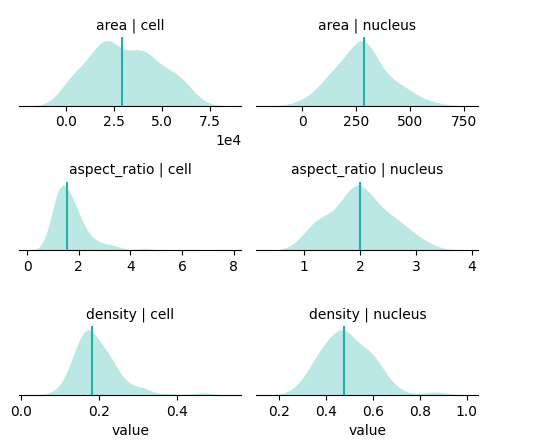

In [8]:
bt.pl.shape_stats(sdata)


In [9]:
res = 0.1
bt.tl.flux(sdata, method="radius", res=res, recompute=True)


Embedding:   0%|          | 0/3 [00:00<?, ?it/s]/home/irma/.local/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/irma/.local/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
Done. 🍱: 100%|██████████| 3/3 [00:21<00:00,  7.13s/it] 


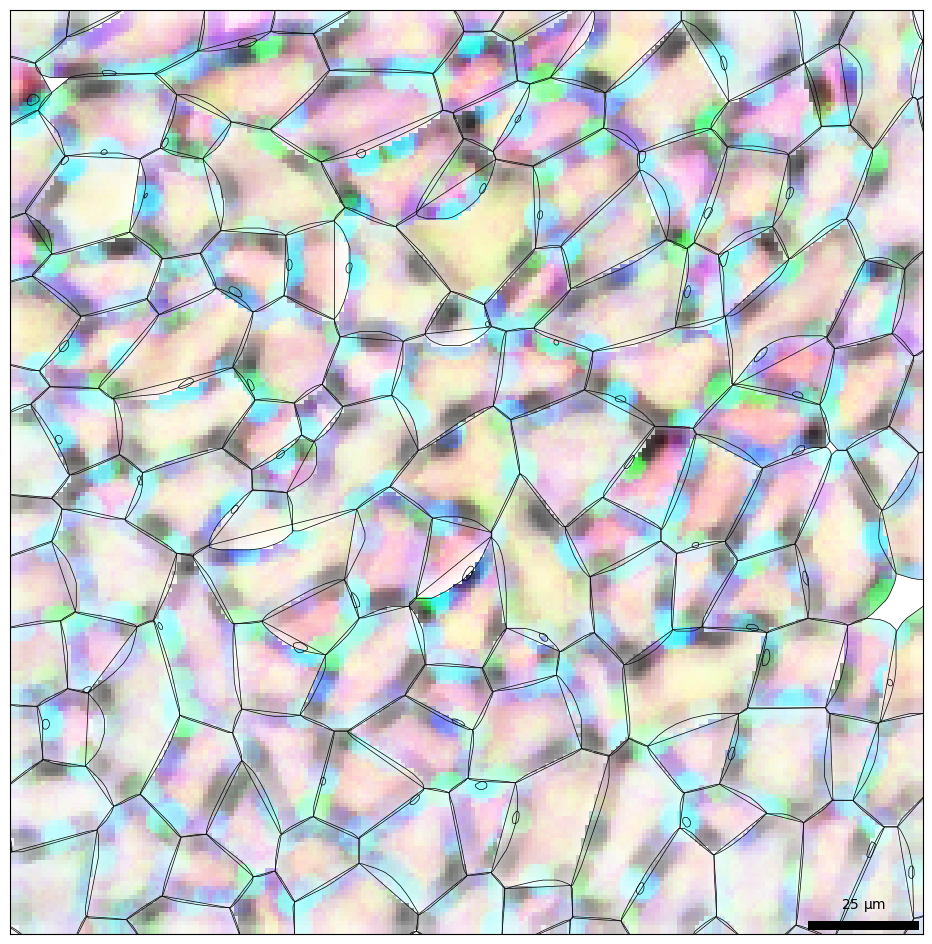

In [10]:
fig, ax = plt.subplots(figsize=(12, 12))
bt.pl.flux(sdata, res=res, ax=ax)


Optimizing # of clusters:   0%|          | 0/3 [00:00<?, ?it/s]

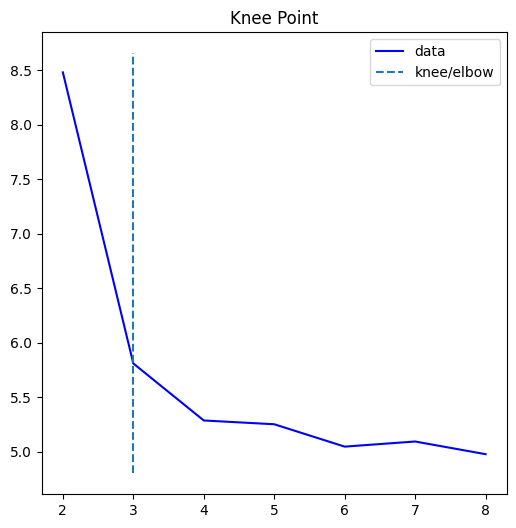

Done: 100%|██████████| 3/3 [00:16<00:00,  5.36s/it]                   


In [11]:
bt.tl.fluxmap(sdata, res=res, min_count=100, plot_error=True)


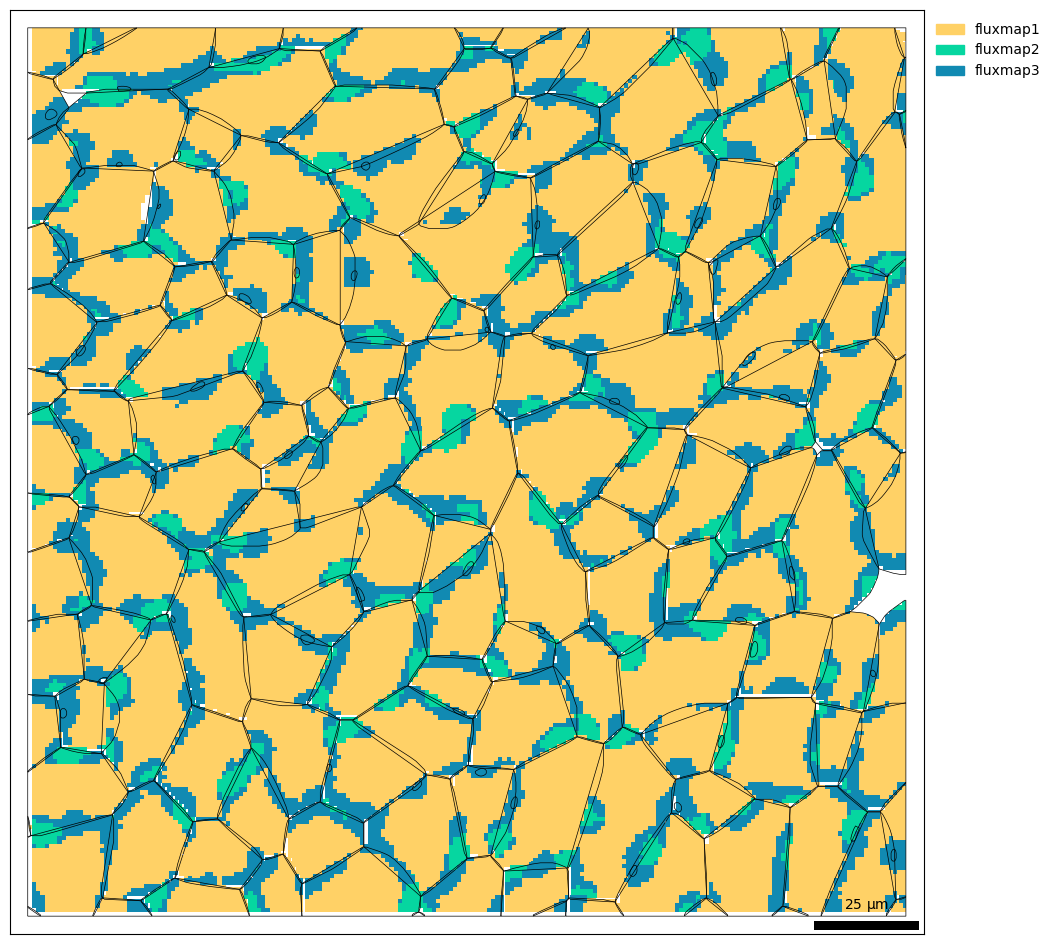

In [12]:
fig, ax = plt.subplots(figsize=(12, 12))
bt.pl.fluxmap(sdata, palette=bt.colors.bento6, ax=ax)


In [39]:
print(sdata.tables["table"].shape)

(152, 567)


In [13]:
bt.tl.lp(sdata)


Batches:   0%|          | 0/76 [00:00<?, ?it/s]/home/irma/.local/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/irma/.local/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
Batches: 100%|██████████| 76/76 [01:55<00:00,  1.52s/it]


Done 🍱


Batches:   0%|          | 0/76 [00:00<?, ?it/s]/home/irma/.local/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/irma/.local/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
Batches: 100%|██████████| 76/76 [00:35<00:00,  2.15it/s]


Done 🍱


In [40]:
print(sdata.tables["table"].n_obs)

152


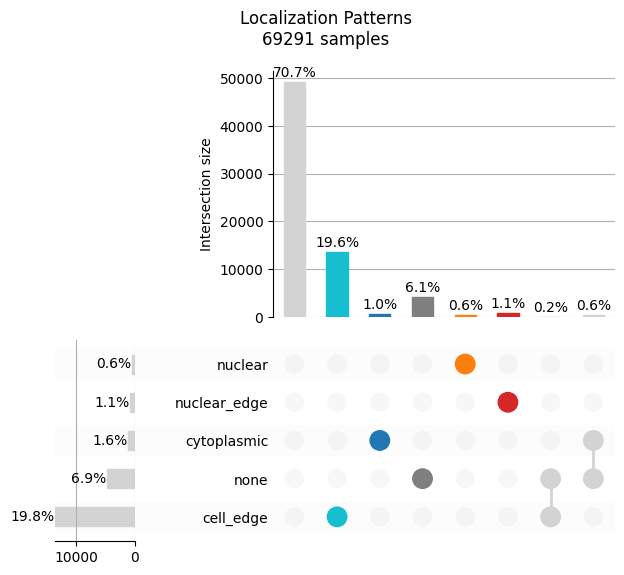

In [14]:
bt.pl.lp_dist(sdata)


In [15]:
bt.tl.lp_stats(sdata)


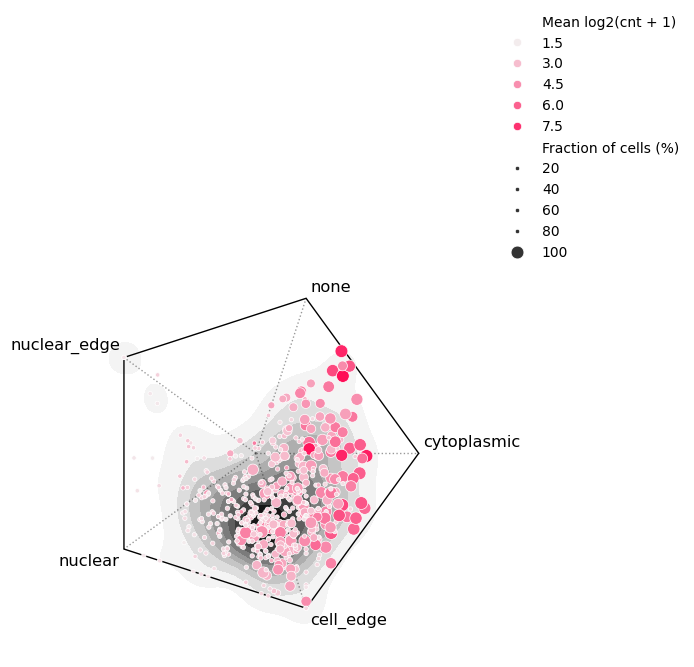

In [16]:
bt.pl.lp_genes(sdata, sizes=(10, 85), size_norm=(90, 100))


In [17]:
bt.geo.overlay(
    sdata,
    s1="cell_boundaries",
    s2="nucleus_boundaries",
    name="cytoplasm",
    how="difference",
)


Done 🍱: 100%|██████████| 3/3 [00:02<00:00,  1.17it/s]        


In [18]:
bt.tl.coloc_quotient(sdata, shapes=["cytoplasm", "nucleus_boundaries"])

Batches:   0%|          | 0/76 [00:00<?, ?it/s]/home/irma/.local/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/irma/.local/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
Batches:   0%|          | 0/76 [00:00<?, ?it/s]/home/irma/.local/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed

In [24]:
print(sdata)
print(sdata.tables.keys())
print(sdata.shapes.keys())
print(sdata.points.keys())

SpatialData object, with associated Zarr store: /home/irma/Documents/ST/Bento/sample_0_spatialdata_prepped_filtered.zarr
├── Points
│     ├── 'cell_boundaries_raster': DataFrame with shape: (<Delayed>, 583) (2D points)
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 10) (2D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (152, 18) (2D shapes)
│     ├── 'cytoplasm': GeoDataFrame shape: (152, 2) (2D shapes)
│     ├── 'fluxmap1': GeoDataFrame shape: (152, 2) (2D shapes)
│     ├── 'fluxmap2': GeoDataFrame shape: (152, 2) (2D shapes)
│     ├── 'fluxmap3': GeoDataFrame shape: (152, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (57, 6) (2D shapes)
└── Tables
      └── 'table': AnnData (152, 567)
with coordinate systems:
    ▸ 'global', with elements:
        cell_boundaries_raster (Points), transcripts (Points), cell_boundaries (Shapes), cytoplasm (Shapes), fluxmap1 (Shapes), fluxmap2 (Shapes), fluxmap3 (Shapes), nucleus_boundaries (Shapes)


Preparing tensor...
:running: Decomposing tensor...


Device cuda: 100%|██████████| 5/5 [03:51<00:00, 46.37s/it]

:heavy_check_mark: Done.


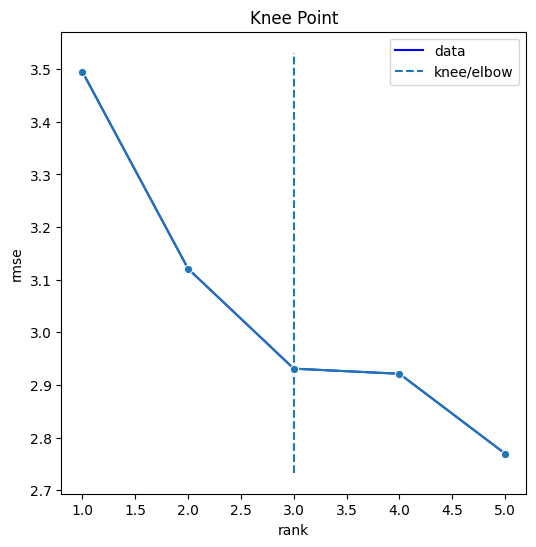

In [19]:
bt.tl.colocation(sdata, ranks=range(1, 6))


In [26]:
table = sdata.tables["table"]

print(table)
print("uns:", table.uns.keys())
print("obsm:", table.obsm.keys())
print("varm:", table.varm.keys())
print("layers:", table.layers.keys())

AnnData object with n_obs × n_vars = 152 × 567
    obs: 'cell_boundaries', 'region'
    uns: 'spatialdata_attrs', 'clq', 'tensor', 'tensor_labels', 'tensor_names', 'factors', 'factors_error'
uns: odict_keys(['spatialdata_attrs', 'clq', 'tensor', 'tensor_labels', 'tensor_names', 'factors', 'factors_error'])
obsm: KeysView(AxisArrays with keys: )
varm: KeysView(AxisArrays with keys: )
layers: KeysView(Layers with keys: )


In [29]:
all_fibres = set(
    sdata.shapes["cell_boundaries"].index.astype(str)
)

rnacoloc_fibres = set(
    sdata.tables["table"].uns["tensor_labels"]["cell_boundaries"].astype(str)
)

excluded_fibres = sorted(
    all_fibres - rnacoloc_fibres,
    key=int
)

print("All fibres:", len(all_fibres))
print("RNAcoloc fibres:", len(rnacoloc_fibres))
print("Excluded fibres:", excluded_fibres)

All fibres: 152
RNAcoloc fibres: 149
Excluded fibres: ['1', '2', '27']


In [32]:
factors = table.uns["factors"]

print(type(factors))
print(factors.keys())

for k, v in factors.items():
    print(k, type(v), getattr(v, "shape", None))

<class 'dict'>
dict_keys([1, 2, 3, 4, 5])
1 <class 'list'> None
2 <class 'list'> None
3 <class 'list'> None
4 <class 'list'> None
5 <class 'list'> None


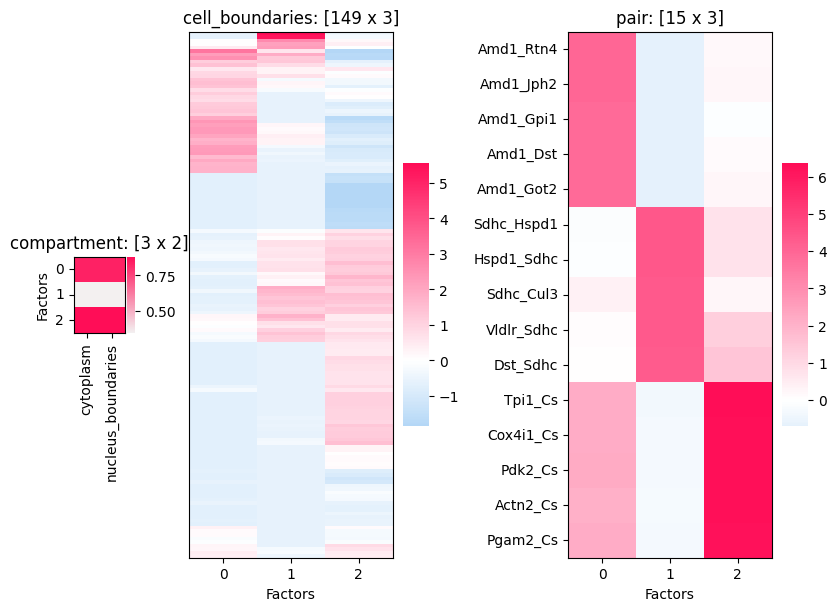

In [20]:
bt.pl.colocation(sdata, rank=3)


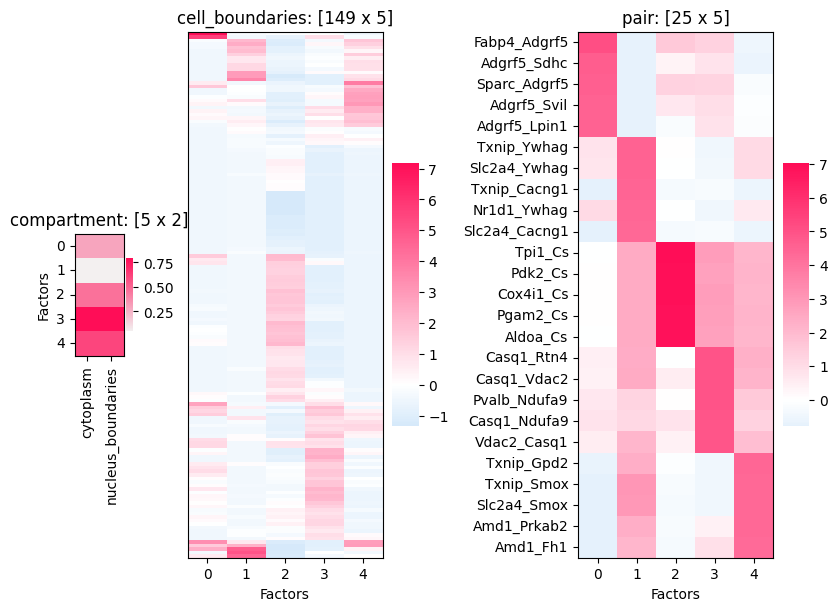

In [21]:
bt.pl.colocation(sdata, rank=5)


In [22]:
len(sdata.shapes["cell_boundaries"])

152

In [44]:
points = bt.ut.get_points(
    sdata,
    points_key="transcripts",
    astype="pandas",
    sync=True
)

for fibre in ["1", "2", "27"]:
    sub = points[points["cell_boundaries"].astype(str) == fibre]

    gene_counts = sub["feature_name"].value_counts()
    passing = gene_counts[gene_counts >= 10]

    print(f"\nFibre {fibre}")
    print("Total transcripts:", len(sub))
    print("Genes with >=10 transcripts:", len(passing))
    print(passing)


Fibre 1
Total transcripts: 96
Genes with >=10 transcripts: 0
Series([], Name: count, dtype: int64)

Fibre 2
Total transcripts: 97
Genes with >=10 transcripts: 1
feature_name
Myh1    10
Name: count, dtype: int64

Fibre 27
Total transcripts: 112
Genes with >=10 transcripts: 0
Series([], Name: count, dtype: int64)


In [ ]:
print(sdata)
print(sdata.tables)

SpatialData object, with associated Zarr store: /home/irma/Documents/ST/Bento/sample_0_spatialdata_prepped_filtered.zarr
├── Points
│     ├── 'cell_boundaries_raster': DataFrame with shape: (<Delayed>, 583) (2D points)
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 10) (2D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (152, 18) (2D shapes)
│     ├── 'cytoplasm': GeoDataFrame shape: (152, 2) (2D shapes)
│     ├── 'fluxmap1': GeoDataFrame shape: (152, 2) (2D shapes)
│     ├── 'fluxmap2': GeoDataFrame shape: (152, 2) (2D shapes)
│     ├── 'fluxmap3': GeoDataFrame shape: (152, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (57, 6) (2D shapes)
└── Tables
      └── 'table': AnnData (152, 567)
with coordinate systems:
    ▸ 'global', with elements:
        cell_boundaries_raster (Points), transcripts (Points), cell_boundaries (Shapes), cytoplasm (Shapes), fluxmap1 (Shapes), fluxmap2 (Shapes), fluxmap3 (Shapes), nucleus_boundaries (Shapes)


In [ ]:
adata = sdata.tables["table"]

print("AnnData shape:", adata.shape)
print("uns keys:", adata.uns.keys())

for key in ["clq", "tensor", "tensor_labels", "tensor_names", "factors"]:
    print("\n", key)
    print(type(adata.uns[key]))

AnnData shape: (152, 567)
uns keys: odict_keys(['spatialdata_attrs', 'clq', 'tensor', 'tensor_labels', 'tensor_names', 'factors', 'factors_error'])

 clq
<class 'dict'>

 tensor
<class 'numpy.ndarray'>

 tensor_labels
<class 'dict'>

 tensor_names
<class 'list'>

 factors
<class 'dict'>


In [ ]:
adata = sdata.tables["table"]

for k, v in adata.uns["factors"].items():
    print("\nFACTOR KEY:", k)
    print("type:", type(v))
    print("shape:", getattr(v, "shape", None))
    print(v.head() if hasattr(v, "head") else v)


FACTOR KEY: 1
type: <class 'list'>
shape: None
[array([[1.3976482],
       [1.3976482]], dtype=float32), array([[9.72956710e-04],
       [6.41429484e-01],
       [1.41736782e+00],
       [8.69815826e-01],
       [2.67029732e-01],
       [1.26289845e+00],
       [1.08727050e+00],
       [4.79865193e-01],
       [4.51083779e-01],
       [1.34225130e+00],
       [6.40129805e-01],
       [4.03293461e-01],
       [6.21758938e-01],
       [9.22054052e-01],
       [1.09195113e+00],
       [1.01108110e+00],
       [3.99287373e-01],
       [1.16031671e+00],
       [1.16763496e+00],
       [1.21076536e+00],
       [9.38631535e-01],
       [9.52815056e-01],
       [1.07849348e+00],
       [5.20453990e-01],
       [1.40779579e+00],
       [1.24577637e-04],
       [2.48701572e-01],
       [9.49861526e-01],
       [1.77179229e+00],
       [8.94866347e-01],
       [1.95463657e-01],
       [1.18800676e+00],
       [1.34740937e+00],
       [1.26038945e+00],
       [3.58224571e-01],
       [5.83387077e

In [ ]:
print("tensor shape:", adata.uns["tensor"].shape)
print("tensor names:", adata.uns["tensor_names"])

for k, v in adata.uns["tensor_labels"].items():
    print("\nLABEL:", k)
    print(type(v))
    print(len(v))
    print(v[:10] if hasattr(v, "__getitem__") else v)

tensor shape: (2, 149, 154857)
tensor names: ['compartment', 'cell_boundaries', 'pair']

LABEL: compartment
<class 'numpy.ndarray'>
2
['cytoplasm' 'nucleus_boundaries']

LABEL: cell_boundaries
<class 'numpy.ndarray'>
149
['0' '10' '100' '101' '102' '103' '104' '105' '106' '107']

LABEL: pair
<class 'numpy.ndarray'>
154857
['Abcb4_Abcb4' 'Abcb4_Acaa2' 'Abcb4_Acacb' 'Abcb4_Acadl' 'Abcb4_Acadm'
 'Abcb4_Acox1' 'Abcb4_Acsl1' 'Abcb4_Actc1' 'Abcb4_Actn2' 'Abcb4_Adgrf5']
